In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


In [2]:
curv_dir ='/home/u0890475/Documents/SW_analysis_result/amr4/curvature'
strainrate_dir = '/home/u0890475/Documents/SW_analysis_result/amr4/strainrate'

In [5]:
curv_files=sorted([os.path.join(curv_dir,f) for f in os.listdir(curv_dir) if f.endswith('.csv')],)
strainrate_files=sorted([os.path.join(strainrate_dir,f) for f in os.listdir(strainrate_dir) if f.endswith('.csv')],)


In [7]:
def curvature_process(d1,yh2_u):
    df1 = pd.read_csv(d1)
    # calculate progress variable
    df1['c'] = 1 - df1['Y(H2)']/yh2_u
    df_ff = df1[(df1['c'] >=0.495)&(df1['c'] <=0.505)]
    df_ff_min=df_ff.loc[df_ff.groupby('y_grid')['x_grid'].idxmin()].copy()
    frontmost =df_ff_min['x_grid'].min()
    return df_ff_min,frontmost


def strainrate(d1):
    df1 = pd.read_csv(d1)

    sr_mean = df1['div_u'].mean()
    sr_median = df1['div_u'].replace([np.inf, -np.inf], np.nan).median()
    return sr_mean, sr_median

In [91]:
strainrate_files[0]

'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate/plt70800_strain_rate.csv'

In [95]:
curv_files[0]

'/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt70800_curvature.csv'

In [11]:
all_ff_min=[]
frontmost_list=[]
sr_mean_list=[]
for i in range(len(curv_files)):
    df_ff_min,frontmost=curvature_process(
        curv_files[i],
        yh2_u=0.012181,
    )
    timestep= curv_files[i].split('/')[-1]
    frontmost_list.append({
        'file':timestep,
        'frontmost':frontmost,
    })

df_frontmost=pd.DataFrame(frontmost_list)

In [13]:
for i in range(len(strainrate_files)):
    timestep= strainrate_files[i].split('/')[-1]
    sr_mean,sr_median=strainrate(strainrate_files[i])
    sr_mean_list.append({
        'file':timestep,
        'sr_mean':sr_mean,
        'sr_median':sr_median,
    })
    print(f'Time step {timestep} is finished.')

df_sr_mean=pd.DataFrame(sr_mean_list)

Time step plt70800_strain_rate.csv is finished.
Time step plt71000_strain_rate.csv is finished.
Time step plt71200_strain_rate.csv is finished.
Time step plt71400_strain_rate.csv is finished.
Time step plt71600_strain_rate.csv is finished.
Time step plt71800_strain_rate.csv is finished.
Time step plt72000_strain_rate.csv is finished.
Time step plt72200_strain_rate.csv is finished.
Time step plt72400_strain_rate.csv is finished.
Time step plt72600_strain_rate.csv is finished.
Time step plt72800_strain_rate.csv is finished.
Time step plt73000_strain_rate.csv is finished.
Time step plt73200_strain_rate.csv is finished.
Time step plt73400_strain_rate.csv is finished.
Time step plt73600_strain_rate.csv is finished.
Time step plt73800_strain_rate.csv is finished.
Time step plt74000_strain_rate.csv is finished.
Time step plt74200_strain_rate.csv is finished.
Time step plt74400_strain_rate.csv is finished.
Time step plt74600_strain_rate.csv is finished.
Time step plt74800_strain_rate.csv is fi

In [15]:
df_frontmost['movement']='stationary'
for i in range(len(df_frontmost)-1):
    x1=df_frontmost.loc[i,'frontmost']
    x2=df_frontmost.loc[i+1,'frontmost']
    if x2>x1:
        movement='backward'
    elif x2<x1:
        movement='forward'
    else:
        movement='stationary'
    df_frontmost.loc[i+1,'movement']=movement



In [21]:
df_plot=df_sr_mean.copy()
df_plot['movement']=df_frontmost['movement']

# remove first point
df_plot=df_plot.iloc[2:].copy()

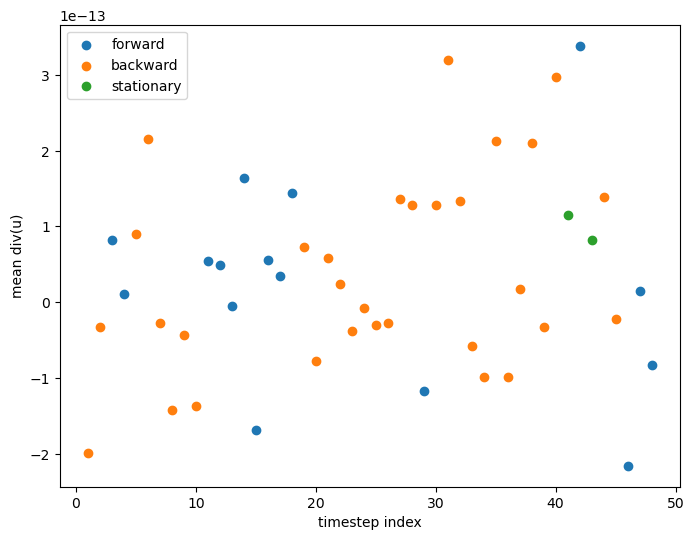

In [19]:
import matplotlib.pyplot as plt

forward=df_plot[df_plot['movement']=='forward']
backward=df_plot[df_plot['movement']=='backward']
stationary=df_plot[df_plot['movement']=='stationary']

plt.figure(figsize=(8,6))

plt.scatter(
    forward.index,
    forward['sr_mean'],
    label='forward',
)

plt.scatter(
    backward.index,
    backward['sr_mean'],
    label='backward',
)

plt.scatter(
    stationary.index,
    stationary['sr_mean'],
    label='stationary',
)

plt.ylabel('mean div(u)')
plt.xlabel('timestep index')
plt.savefig('./result/flamefront vs strainrate.png',dpi=600)

plt.legend()

plt.show()

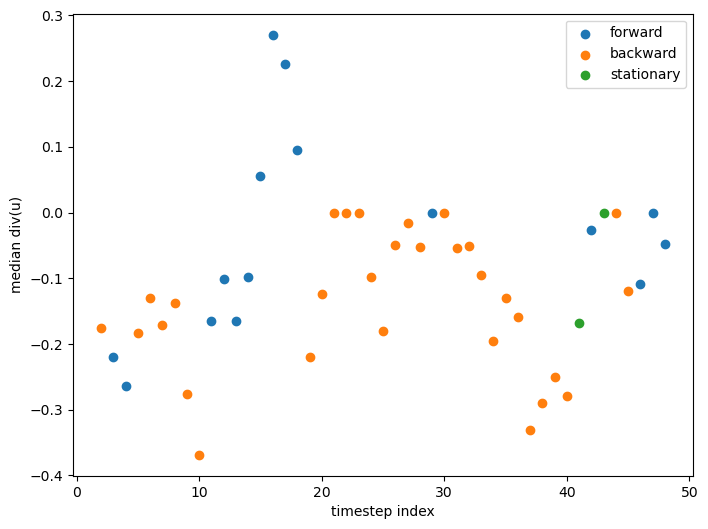

In [29]:
import matplotlib.pyplot as plt

forward=df_plot[df_plot['movement']=='forward']
backward=df_plot[df_plot['movement']=='backward']
stationary=df_plot[df_plot['movement']=='stationary']

plt.figure(figsize=(8,6))

plt.scatter(
    forward.index,
    forward['sr_median'],
    label='forward',
)

plt.scatter(
    backward.index,
    backward['sr_median'],
    label='backward',
)

plt.scatter(
    stationary.index,
    stationary['sr_median'],
    label='stationary',
)

plt.ylabel('median div(u)')
plt.xlabel('timestep index')
plt.savefig('./result/flamefront vs strainrate(median).png',dpi=600)

plt.legend()

plt.show()

In [27]:
df_sr_mean

,file,sr_mean,sr_median
0,plt70800_strain_rate.csv,-6.002653e-14,-0.093333
1,plt71000_strain_rate.csv,-1.991790e-13,-0.261159
2,plt71200_strain_rate.csv,-3.274175e-14,-0.174915
3,plt71400_strain_rate.csv,8.185436e-14,-0.219603
4,plt71600_strain_rate.csv,1.091392e-14,-0.263517
5,plt71800_strain_rate.csv,9.003980e-14,-0.183784
6,plt72000_strain_rate.csv,2.155498e-13,-0.130631
7,plt72200_strain_rate.csv,-2.728479e-14,-0.170378
8,plt72400_strain_rate.csv,-1.418809e-13,-0.138092
9,plt72600_strain_rate.csv,-4.365566e-14,-0.276132


In [69]:
def curvature_plot(d1,yh2_u):
    df1 = pd.read_csv(d1)
    # calculate progress variable
    df1['c'] = 1 - df1['Y(H2)']/yh2_u
    df_ff = df1[(df1['c'] >=0.495)&(df1['c'] <=0.505)].reset_index(drop=True)
    #df_ff_min=df_ff.loc[df_ff.groupby('y_grid')['x_grid'].idxmin()].copy()
    idx_min = df_ff['x_grid'].idxmin()
    ffx,ffy,ffz =df_ff['x_grid'].iloc[idx_min],df_ff['y_grid'].iloc[idx_min],df_ff['z_grid'].iloc[idx_min],
    df_ffz = df_ff[df_ff['z_grid'] ==ffz]
    plt.plot(df_ff['x_grid'],df_ff['y_grid'],marker='.',markersize=1,)
    
    plt.show()
    return ffx,ffy,ffz

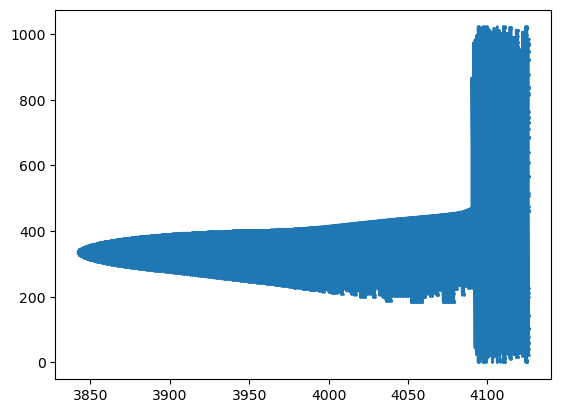

(3842, 332, 0)

In [71]:
curvature_plot('/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt70800_curvature.csv',yh2_u=0.012181,)

In [179]:
df1= pd.read_csv('/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt73400_curvature.csv')

In [183]:
df1['c'] =  1- df1['Y(H2)']/0.012181
df1_f= df1[df1['c']>=0.495]
df_ffm =df1_f.loc[df1_f.groupby('y_grid')['x_grid'].idxmin()].copy()


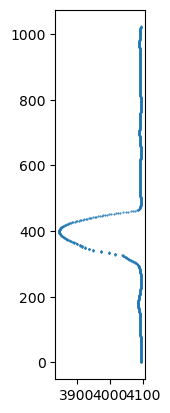

In [193]:
plt.plot(df_ffm['x_grid'],df_ffm['y_grid'],'.',markersize=1)
plt.gca().set_aspect('equal')
plt.show()

In [73]:
def plot_strainrate_slice(
    d1,
    d2,
    yh2_u,
    method=1,
    file_label='',
    esr=10000,
):
    
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,9))
    # d1: strain rate
    # d2: curvature
    df = pd.read_csv(d1)
    name = d1.split('/')[-1].split('.')[0]
    
    dfcurv = pd.read_csv(d2)
    dfcurv['c'] = 1 - dfcurv['Y(H2)']/yh2_u
    df_ff = dfcurv[(dfcurv['c'] >=0.495)].reset_index(drop=True)
    #df_fi = dfcurv[(dfcurv['c'] >=0.1)].reset_index(drop=True)
    #df_f05 = dfcurv[(dfcurv['c'] >=0.01)].reset_index(drop=True)
    #idx_min = df_ff['x_grid'].idxmin()
    ffz =df_ff['z_grid'].iloc[idx_min]
    #ffzi =df_fi['z_grid'].iloc[idx_min]
    df_ffz = df_ff[df_ff['z_grid'] ==ffz]
    #df_ffzi = df_fi[df_fi['z_grid'] ==ffz]
    #df_ffz05 = df_f05[df_f05['z_grid'] ==ffz]
    df_ffm = df_ffz.loc[df_ffz.groupby('y_grid')['x_grid'].idxmin()].copy()
    #df_ffi = df_ffzi.loc[df_ffzi.groupby('y_grid')['x_grid'].idxmin()].copy()
    #df_ff05 = df_ffz05.loc[df_ffz05.groupby('y_grid')['x_grid'].idxmin()].copy()
    # thats where the flame is located at chosen c=0.5 as the flame location
    #plt.plot(df_ff05['x_grid'],df_ff05['y_grid'],'-.',markersize=2,color='lightgray',label='c=0.01')
    #plt.plot(df_ffi['x_grid'],df_ffi['y_grid'],'.',markersize=2,color='dimgrey',label='c=0.1')
    plt.plot(df_ffm['x_grid'],df_ffm['y_grid'],'.',markersize=2,color='black',label='c=0.5')
    
    df2=df[df['z_grid']==ffz].copy()
    for i in range(8):
        df_zcut = df_ff[df_ff['z_grid']==i]
        df_z01 = df_zcut[df_zcut['c']>=0.05]
        df_z05 = df_zcut[df_zcut['c']>=0.5]
        df_ff01 = df_z01.loc[df_z01.groupby('y_grid')['x_grid'].idxmin()].copy()
        df_ff05 = df_z05.loc[df_z05.groupby('y_grid')['x_grid'].idxmin()].copy()

        plt.plot(df_ff01['x_grid'],df_ff01['y_grid'],'.',markersize=2,color='lightgray',label='c=0.05')
        plt.plot(df_ff05['x_grid'],df_ff05['y_grid'],'.',markersize=2,color='lightgray',label='c=0.5')
        df2=df[df['z_grid']==i].copy()
    # method 1, directly plot strain rate with normal scale
    if(method==1):
        divu_grid=df2.pivot_table(
            index='y_grid',
            columns='x_grid',
            values='div_u',
            aggfunc='median',
        )
        levels=np.linspace(
            -2000,
            2000,
            100,
        )
        vmin=-2000
        vmax=2000
        X=divu_grid.columns.values
        Y=divu_grid.index.values
        Z=divu_grid.values
        cf=plt.contourf(
            X,
            Y,
            Z,
            levels=levels,
            cmap='seismic',
            vmin=vmin,
            vmax=vmax,
        )
             
        X=divu_grid.columns.values
        Y=divu_grid.index.values
        Z=divu_grid.values
        plt.gca().set_aspect('equal')
        plt.colorbar(cf,label = 'Strain Rate')
        plt.xlabel('x_grid')
        plt.ylabel('y_grid')
        plt.title(f'z_grid={ffz}')


    # method 2
    elif(method==2):
        df2['log_abs_div_u'] =np.log10(abs(df2['div_u']+1e-5))
        divu_grid=df2.pivot_table(
            index='y_grid',
            columns='x_grid',
            values='log_abs_div_u',
            aggfunc='median',
        )
        levels=np.linspace(
            0,
            10,
            51,
        )
        vmin=-10
        vmax=10
        X=divu_grid.columns.values
        Y=divu_grid.index.values
        Z=divu_grid.values
        cf=plt.contourf(
            X,
            Y,
            Z,
            levels=levels,
            cmap='YlGn',
            vmin=vmin,
            vmax=vmax,
        )
             
        X=divu_grid.columns.values
        Y=divu_grid.index.values
        Z=divu_grid.values
        plt.gca().set_aspect('equal')
        plt.colorbar(cf,label='Absolute Strain Rate in Log10-scale')
        plt.xlabel('x_grid')
        plt.ylabel('y_grid')
        plt.title(f'z_grid={ffz}')

    # for this section, highlight the region that has higher value than the extinction strain rate from cantera
    """

    """

    plt.ylim(0,1024)
    plt.xlim(3510,4050)
    plt.tight_layout()
    plt.legend()
    #plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_strainrate.png',dpi=600)
    plt.show()

In [421]:
# The section above is copied as the function backup
# get dudx
cf_x=plt.contourf(X,Y,dudx_grid.values,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax,)
cbar =plt.colorbar(cf_x,label='Strain Rate in power of 10-scale')
cbar.formatter=FuncFormatter(log_label)
cbar.update_ticks()
plt.xlabel('x_grid')
plt.ylabel('y_grid')
plt.title(f'z_grid={i} w/ max abs dudx :{round(max(dudx_grid.values),2)} 1/s.')
plt.ylim(0,1024)
plt.xlim(3510,4050)
plt.tight_layout()
plt.legend()
plt.show()


In [35]:
def plot_flame_contour(df_ff01,df_ff05):
    fig,ax = plt.subplots(figsize=(12,9))
    ax.plot(df_ff01['x_grid'],df_ff01['y_grid'],'.',markersize=2,color='dimgrey',label='c=0.05')
    ax.plot(df_ff05['x_grid'],df_ff05['y_grid'],'.',markersize=2,color='black',label='c=0.5')
    
    return fig,ax





def plot_sr_dudx(df_ff01,df_ff05,df,ax,sr_threshold):
    fig,ax=plot_flame_contour(df_ff01,df_ff05)
    pn_dudx = np.where(df['dudx']>0,1,-1)
    log_abs_dudx = np.log10(abs(pn_dudx+1e-5))
    df['pn_log_dudx'] = pn_dudx* log_abs_dudx
    divu_grid=df.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_dudx',
        aggfunc='median',
    )
    X=divu_grid.columns.values
    Y=divu_grid.index.values
    Z=divu_grid.values
    max_sr = max(Z)
    levels=np.linspace(-4,4,33,)
    vmin=-4
    vmax=4
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax,)
    cf2=ax.contourf(X,Y,np.abs(Z)>=np.log10(sr_threshold),levels=[0.5,1],hatches=['xx'],alpha=0.5,)

    ax.set_aspect('equal')
    ax.set_xlim(3510,4050)
    ax.set_ylim(0,1024)
    ax.set_xlabel('x_grid')
    ax.set_ylabek('y_grid')
    ax.set_title(f'z_grid={i} w/ max abs dudx :{round(max_sr,2)} 1/s.')
    ax.legend()
    plt.tight_layout()
    plt.show()
    

    return
def plot_strainrate_slice(
    d1,
    d2,
    yh2_u,
    method=1,
    file_label='',
    esr=10000,
    sr_threshold=1000,
):
    from matplotlib.ticker import FuncFormatter
    import matplotlib.pyplot as plt
    def log_label(x,pos):
        if np.isclose(x,0):
            return "0"
        sign= "-" if x<0 else ""
        exp=int(np.round(abs(x)))
        return rf"${sign}10^{{{abs(int(x))}}}$"
    #plt.figure(figsize=(12,9))
    # d1: strain rate
    # d2: curvature
    df = pd.read_csv(d1,usecols=['dudx','dvdy','dwdz','x_grid','y_grid','z_grid'])
    try:
        df['div_u']= df['dudx'] + df['dvdy'] + df['dwdz']
    except:
        pass
    #print(df['z_grid'].max(), df['z_grid'].min())
    try:
        df = df.drop(columns=["T","ux","uy","uz"])
    except:
        print("Temperature is not included or removed already!!!")
        
    #df_sr = df[ (df['div_u'] >= sr_threshold) | (df['div_u']<= -sr_threshold) ].copy()
    name = d1.split('/')[-1].split('.')[0]
    
    
    
    dfcurv_r = pd.read_csv(d2)
    dfcurv_r = dfcurv_r[(dfcurv_r['x_grid']>=3510) & (dfcurv_r['x_grid']<=4060)]
    dfcurv_r['c'] = 1 - dfcurv_r['Y(H2)']/yh2_u
    
    # find the most front point
    ff_idx = dfcurv_r[dfcurv_r['c']>=0.05]['x_grid'].idxmin()
    ff_ygrid = dfcurv_r['y_grid'].iloc[ff_idx]
    ff_xgrid = dfcurv_r['x_grid'].iloc[ff_idx]
    df_sr_verticalcut = df[(df['y_grid'] ==ff_ygrid) & (df['x_grid'] >=(ff_xgrid+50))  ]
    
    
    df= df.set_index(['x_grid','y_grid','z_grid']).copy()
    
    dfcurv = dfcurv_r.join(df, on=[ 'x_grid','y_grid','z_grid']) 

    df_sr_verticalcut['pn_div_u'] = np.where(df_sr_verticalcut["div_u"]>0,1,-1 )

    df_sr_verticalcut['log_abs_div_u'] =np.log10(abs(df_sr_verticalcut['div_u']+1e-5))
    df_sr_verticalcut['pn_log_div_u'] = df_sr_verticalcut['pn_div_u'] * df_sr_verticalcut['log_abs_div_u']

    pvt2 = df_sr_verticalcut.pivot_table(index='z_grid',columns='x_grid',values='pn_log_div_u',aggfunc='median',)
    X2=pvt2.columns.values
    Y2=pvt2.index.values
    Z2=pvt2.values
    
    levels=np.linspace(
        -4,
        4,
        33,
    )
    vmin=-4
    vmax=4
    #mask = np.abs(Z)>= sr_threshold
    fig, ax = plt.subplots(figsize=(12,9))
    cf_vertical=ax.contourf(
        X2,
        Y2,
        Z2,
        levels=levels,
        cmap='bwr',
        vmin=vmin,
        vmax=vmax,
    )
    
    ax.set_aspect("equal",adjustable="box")
    
    cbar =plt.colorbar(cf_vertical,ax=ax,label='Strain Rate in power of 10-scale')
    cbar.formatter=FuncFormatter(log_label)
    cbar.update_ticks()
    ax.set_xlabel('X_grid')
    ax.set_ylabel('Z_grid')
    ax.set_ylim(0,32)
    ax.set_xlim(3850,3900)
    ax.set_title(f'y_grid={ff_ygrid} Vertical Slice')
    plt.show()

    
    
    for i in range(6,8):
        #fig,ax = plt.subplots(figsize=(12,9))
        df_zcut = dfcurv[dfcurv['z_grid']==i]
        df_z01 = df_zcut[df_zcut['c']>=0.05]
        df_z05 = df_zcut[df_zcut['c']>=0.5]
        df_zcold = df_zcut[df_zcut['c']<=0.5]
        max_sr = max(abs(df_zcold['div_u']))
        df_ff01 = df_z01.loc[df_z01.groupby('y_grid')['x_grid'].idxmin()].copy()
        df_ff05 = df_z05.loc[df_z05.groupby('y_grid')['x_grid'].idxmin()].copy()
        
        # trying to get all strain rate value before the flame front(underconstruction)
        

        #ax.plot(df_ff01['x_grid'],df_ff01['y_grid'],'.',markersize=2,color='dimgrey',label='c=0.05')
        #ax.plot(df_ff05['x_grid'],df_ff05['y_grid'],'.',markersize=2,color='black',label='c=0.5')
        fig,ax = plot_flame_contour(df_ff01,df_ff05)
        # method 1, directly plot strain rate with normal scale
        if method==1:
            print('method1')
    
    
        # method 2
        elif(method==2):
            df =df[df['z_grid']==i]
            df['pn_div_u'] = np.where(df["div_u"]>0,1,-1 )
            df['log_abs_div_u'] =np.log10(abs(df['div_u']+1e-5))
            df['pn_log_div_u'] = df['pn_div_u'] * df['log_abs_div_u']
            plot_sr_dudx(df_ff01,df_ff05,df,ax,sr_threshold)
 
            #max_sr = df2['log_abs_div_u'].max()
            divu_grid=df.pivot_table(
                index='y_grid',
                columns='x_grid',
                values='pn_log_div_u',
                aggfunc='median',
            )

            levels=np.linspace(-4,4,33,)


            vmin=-4
            vmax=4
            X=divu_grid.columns.values
            Y=divu_grid.index.values
            Z=divu_grid.values
            #mask = np.abs(Z)>= sr_threshold
            cf=plt.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax,)
            cf2=plt.contourf(X,Y,np.abs(Z)>=np.log10(sr_threshold),levels=[0.5,1],hatches=['xx'],alpha=0.5,)
               
            plt.gca().set_aspect('equal')
            cbar =plt.colorbar(cf,label='Strain Rate in power of 10-scale')
            cbar.formatter=FuncFormatter(log_label)
            cbar.update_ticks()
            plt.xlabel('x_grid')
            plt.ylabel('y_grid')
            plt.title(f'z_grid={i} w/ max abs combined strain rate :{round(max_sr,2)} 1/s.')

        plt.ylim(0,1024)
        plt.xlim(3510,4050)
        plt.tight_layout()
        plt.legend()
        #plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_strainrate_z={i}.png',dpi=600)
        plt.show()

    
        # for this section, plot the vertical cutof the surface
        

In [33]:
plot_strainrate_slice('/home/u0890475/Documents/SW_analysis_result/amr4/strainrate/amr4_strainrate_p42p5/plt75600_strain_rate.csv',
                      '/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt75600_curvature.csv',
                      yh2_u=0.012181,method=2,file_label='log10')



Temperature is not included or removed already!!!


ValueError: columns overlap but no suffix specified: Index(['x_grid', 'y_grid', 'z_grid'], dtype='object')

In [ ]:
# Batch process of the strain rate plot

"""

for i in range(len(curv_files)):
    plot_strainrate_slice(strainrate_files[i],curv_files[i],yh2_u=0.012181)

"""

In [485]:
import numpy as np
d1 = pd.read_csv('/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt75400_curvature.csv')
d2 = pd.read_csv('/home/u0890475/Documents/SW_analysis_result/amr4/strainrate/plt75400_strain_rate.csv')

In [487]:
d2.columns

Index(['ux', 'uy', 'uz', 'umag', 'div_u', 'x_grid', 'y_grid', 'z_grid'], dtype='object')

In [491]:
d1 = d1[d1['z_grid'] ==0].copy()
#d2 = d2[(d2['x_grid']>=3510 )& (d2['x_grid']<=4050) & (d2['z_grid']==0) ]

d1['c'] = 1- d1['Y(H2)']/0.012181
df_cold = d1[d1['c']<=0.5]
d1_mx = df_cold.loc[df_cold.groupby('y_grid')['x_grid'].idxmax()]
d2_index = d2.set_index(['x_grid','y_grid','z_grid'])
d1_mx_sr = d1_mx.join(d2_index,on=['x_grid','y_grid','z_grid'])
d1_mx_sr

,x_grid,y_grid,z_grid,T,Q,Y(H2),k,c,ux,uy,uz,umag,div_u
4099013,4090,0,0,355.088005,4.281417e+08,0.006287,-32032.742208,0.483833,0.100467,-0.097534,-0.002177,0.140040,367.115031
4099043,4090,1,0,354.179605,4.138939e+08,0.006335,-32028.184271,0.479906,0.099732,-0.103657,-0.002335,0.143864,368.641454
4099073,4090,2,0,353.218939,3.992343e+08,0.006387,-32019.713606,0.475687,0.098988,-0.109684,-0.002526,0.147769,371.408419
4099101,4090,3,0,352.223890,3.844783e+08,0.006441,-32007.982401,0.471211,0.098254,-0.115552,-0.002750,0.151703,374.446873
4099129,4090,4,0,351.211347,3.699124e+08,0.006498,-31993.786784,0.466516,0.097548,-0.121211,-0.003006,0.155617,377.342306
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4133077,4090,1019,0,358.355741,4.818846e+08,0.006112,-31983.792050,0.498213,0.103556,-0.067495,-0.001840,0.123624,374.605416
4133109,4090,1020,0,357.911415,4.744801e+08,0.006138,-32003.547739,0.496097,0.103052,-0.073270,-0.001853,0.126458,371.480005
4133141,4090,1021,0,357.352456,4.651277e+08,0.006169,-32018.382022,0.493587,0.102482,-0.079203,-0.001892,0.129535,369.116968
4133173,4090,1022,0,356.687873,4.540850e+08,0.006204,-32028.146338,0.490696,0.101855,-0.085255,-0.001957,0.132840,367.569176


In [339]:

d1_z0 =d1[d1['z_grid']==0]
d1_z0['div_u'].max()

5999.345301631543

/tmp/ipykernel_2103084/2639765101.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d1_esr['log_abs_div_u'] = np.log10(abs(d1_esr['div_u']+1e-5))


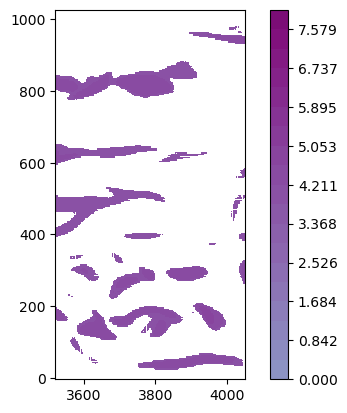

In [419]:
d1_esr = d1[d1['div_u'] >=10000]
d1_esr['log_abs_div_u'] = np.log10(abs(d1_esr['div_u']+1e-5))
divu_grid=d1_esr.pivot_table(
    index='y_grid',
    columns='x_grid',
    values='log_abs_div_u',
    aggfunc='median',
)

X=divu_grid.columns.values
Y=divu_grid.index.values
Z=divu_grid.values
levels=np.linspace(
    0,
    8,
    20,
)
    
cf=plt.contourf(
    X,
    Y,
    Z,
    levels=levels,
    cmap='BuPu', 
    vmin= -10,
    vmax= 10,
)


#plt.plot(d1_esr['x_grid'],d1_esr['y_grid'],c=d1_esr['log_abs_div_u'],cmap='BuPu')
plt.gca().set_aspect('equal')
plt.colorbar(cf)

In [245]:
d1['div_u'].idxmax()

21837164

In [247]:
d1.iloc[21837164]

ux                    2.075484
uy                    1.270873
uz                    0.567040
umag                  2.498857
div_u            216560.292926
x_grid             4097.000000
y_grid              799.000000
z_grid               31.000000
log_abs_div_u         5.335579
Name: 21837164, dtype: float64

In [255]:
import sys
print(sys.version)

3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]


In [111]:
dy =0.0175/1024
# thermal conductivity of phi=0.42 preburnt
k_mixture = 0.04026000133202389

d2 = pd.read_csv('/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt73400_curvature.csv')
d2f = d2[(d2['x_grid']>=3800) &(d2['x_grid']<=4000) & (d2['y_grid']>=200)& (d2['y_grid']<=500) & (d2['z_grid']==0) ]
d2f['dTdz'] = (d2f['T'] - 298)/(dy/2)
d2f['q'] = -(dy**2)*d2f['dTdz']*k_mixture

/tmp/ipykernel_2027783/490581309.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2f['dTdz'] = (d2f['T'] - 298)/(dy/2)
/tmp/ipykernel_2027783/490581309.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2f['q'] = -(dy**2)*d2f['dTdz']*k_mixture


In [113]:
sum(d2f['q'])

-1.2747422988763861

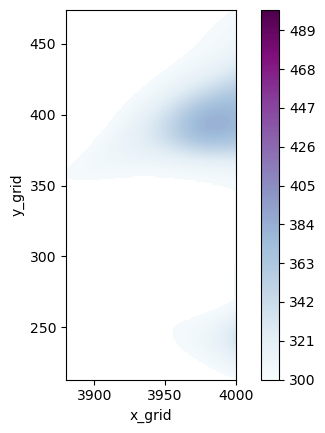

In [34]:
divu_grid=d2f.pivot_table(
    index='y_grid',
    columns='x_grid',
    values='T',
    aggfunc='median',
)

X=divu_grid.columns.values
Y=divu_grid.index.values
Z=divu_grid.values
levels=np.linspace(
    300,
    500,
    201,
)
    
cf=plt.contourf(
    X,
    Y,
    Z,
    levels=levels,
    cmap='BuPu', 
    vmin= 300,
    vmax= 500,
)
plt.xlabel('x_grid')
plt.ylabel('y_grid')
plt.gca().set_aspect('equal')
plt.colorbar(cf)
#plt.savefig('/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/plt75800_temp_at_z=0.png',dpi=600)

In [87]:
def get_wall_heatflux(d1,dx=17.0898e-6,x_grid_lim=[3800,4050],y_grid_lim=None,output_dir = './',textlabel=''):
    import matplotlib.pyplot as plt
    d2 = pd.read_csv(d1)
    filename= d1.split('/')[-1].split('.')[0]
    #d2f = d2[(d2['x_grid']>=3800) &(d2['x_grid']<=4000) & (d2['y_grid']>=200)& (d2['y_grid']<=500) & (d2['z_grid']==0) ]
    if (x_grid_lim is not None) or (y_grid_lim is not None):
        try:
            d2 = d2[(d2['x_grid']>=x_grid_lim[0]) & ( d2['x_grid']<=x_grid_lim[1] )]
        except:

            print('Failed to cut in the x regime! Or no cut request on x regime')
        try:
            d2 = d2[(d2['y_grid']>=y_grid_lim[0]) & ( d2['y_grid']<=y_grid_lim[1] )]
        except:
            
            print('Failed to cut in the y regime! Or no cut request on y regime')

    d2f = d2[d2['z_grid']==0]
    print(f'The T max is {d2f['T'].max()}')
    d2f['dTdz'] = (d2f['T'] - 298)/(dy/2)
    d2f['q'] = -(dy**2)*d2f['dTdz']*k_mixture
    divu_grid=d2f.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='T',
        aggfunc='median',
    )
    plt.figure(figsize=(12,9))
    X=divu_grid.columns.values
    Y=divu_grid.index.values
    Z=divu_grid.values
    levels=np.linspace(
        300,
        450,
        201,
    )
        
    cf=plt.contourf(
        X,
        Y,
        Z,
        levels=levels,
        cmap='BuPu', 
        vmin= 300,
        vmax= 450,
    )
    plt.xlabel('x_grid')
    plt.ylabel('y_grid')
    plt.ylim(0,1024)
    plt.gca().set_aspect('equal')
    plt.colorbar(cf)
    #plt.savefig(f'{output_dir}/{filename}_{textlabel}_at_z=0.png', dpi=600)
    #plt.savefig('/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/plt75800_temp_at_z=0.png',dpi=600)
    plt.show()

    return sum(d2f['q'])


Failed to cut in the y regime! Or no cut request on y regime
The T max is 401.4913638207639


/tmp/ipykernel_2027783/3486771715.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2f['dTdz'] = (d2f['T'] - 298)/(dy/2)
/tmp/ipykernel_2027783/3486771715.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2f['q'] = -(dy**2)*d2f['dTdz']*k_mixture


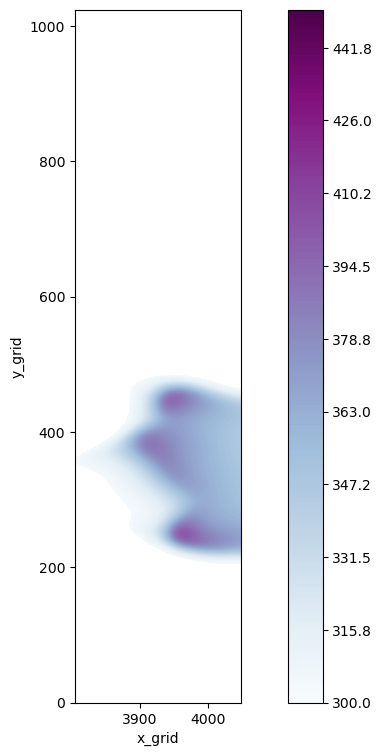

-3.2256618868748994

In [89]:
d1 = '/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt75400_curvature.csv'
get_wall_heatflux(d1)

In [413]:
d1 = pd.read_csv('/home/u0890475/Documents/SW_analysis_result/amr4/strainrate/plt77800_strain_rate.csv')
d1c = pd.read_csv('/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt77800_curvature.csv')
d1=d1[(d1['x_grid'] <=4050) & (d1['x_grid']>=3520)]
d1c['c'] = 1 - d1c['Y(H2)']/yh2_u

In [411]:
d1['x_grid'].min()

3510